# Office Character Classification
This is office character classification. For now, available characters are Angela, Dwight, Jim, Pam, Michael, Kevin. In case of you didn't know, let me introduce you to the characters.

In [2]:
# Imports

from fastai.vision.all import *
from fastai.vision.widgets import *
import urllib.request

In [3]:
# Load model

# MODEL_URL = "https://drive.google.com/file/d/1bdsIlQzKHLCy5FsXKTMf5kD9R8vjQcPD/view?usp=sharing"
# urllib.request.urlretrieve(MODEL_URL, "export.pkl")

path = Path()
learn_inf = load_learner(path/'office_export.pkl', cpu=True)
# learner = load_learner(Path("."), "export.pkl")

btn_upload = widgets.FileUpload()
out_pl = widgets.Output()
lbl_pred = widgets.Label()
pathlib.PosixPath = temp

NotImplementedError: cannot instantiate 'PosixPath' on your system

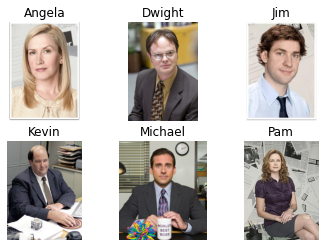

In [4]:

im5 = Image.open(path/'office_images\Pam.jpg')
im2 = Image.open(path/'office_images\Jim.jpg')
im0 = Image.open(path/'office_images\Angela.png')
im1 = Image.open(path/'office_images\Dwight.jpg')
im3 = Image.open(path/'office_images\Kevin.jpg')
im4 = Image.open(path/'office_images\Michael.png')

f, axarr = plt.subplots(2,3)

axarr[0,0].imshow(im0); axarr[0,0].axis('off');axarr[0,0].set_title('Angela');
axarr[0,1].imshow(im1); axarr[0,1].axis('off');axarr[0,1].set_title('Dwight');
axarr[0,2].imshow(im2); axarr[0,2].axis('off');axarr[0,2].set_title('Jim');
axarr[1,0].imshow(im3); axarr[1,0].axis('off');axarr[1,0].set_title('Kevin');
axarr[1,1].imshow(im4); axarr[1,1].axis('off');axarr[1,1].set_title('Michael');
axarr[1,2].imshow(im5); axarr[1,2].axis('off');axarr[1,2].set_title('Pam');

In [5]:
# Create interface

def on_data_change(change):
    lbl_pred.value = ''
    
    # Load Image
    img = PILImage.create(btn_upload.data[-1])
    out_pl.clear_output()
    with out_pl:
        display(img.to_thumb(224,244))
    
    # Predict image
    pred, pred_idx, probs = learn_inf.predict(img)
    
    lbl_pred.value = f'Prediction: {pred}; Probability: {probs[pred_idx]:.04f}'

In [7]:
btn_upload.observe(on_data_change, names=['data'])

# Display Predictions
display(VBox([widgets.Label('Upload your character and let me guess.'), btn_upload, out_pl, lbl_pred]))